<a href="https://colab.research.google.com/github/Sidhazzzzzz/BB84_Quantum_Key_Distribution/blob/main/BB84_Quantum_Key.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



           BB84 PROTOCOL — OUTPUT SUMMARY           
Quantum Sender Bits               : [1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1]
Quantum Sender Bases              : ['x', '+', 'x', 'x', '+', 'x', '+', 'x', '+', 'x', 'x', '+', '+', 'x', 'x', '+', 'x', 'x', 'x', '+', 'x', 'x', 'x', 'x', 'x', '+', '+', 'x', 'x', '+', 'x', 'x', 'x', 'x', '+', '+', 'x', '+', 'x', 'x', 'x', '+', 'x', 'x', 'x', 'x', '+', 'x', 'x', '+']
Quantum Receiver Bases            : ['+', '+', '+', 'x', 'x', '+', 'x', '+', 'x', '+', '+', '+', 'x', 'x', 'x', '+', '+', 'x', 'x', '+', '+', '+', 'x', '+', '+', 'x', '+', 'x', '+', 'x', '+', '+', 'x', '+', 'x', 'x', 'x', '+', '+', '+', 'x', '+', 'x', '+', 'x', '+', 'x', '+', 'x', 'x']
Receiver Measurements             : [0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 

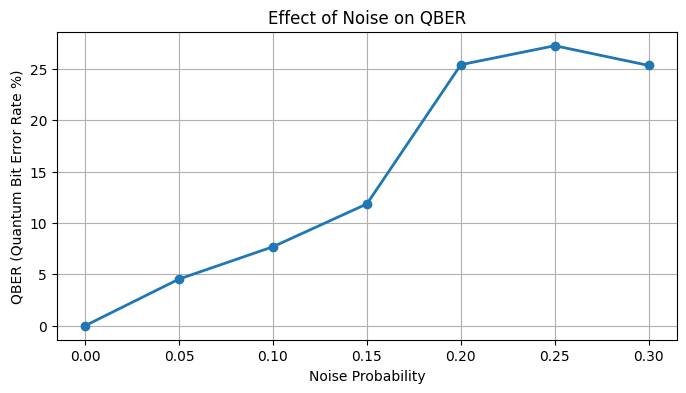


 Graph 2: QBER With vs Without Attack  



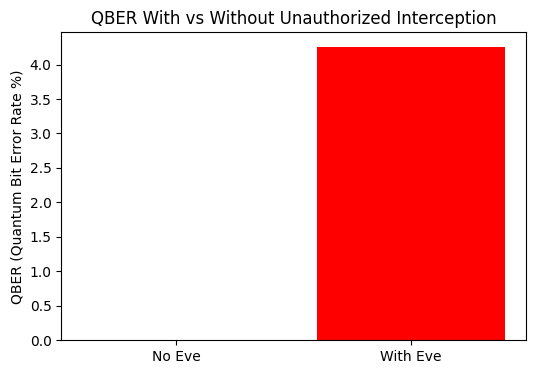

In [ ]:
# This program simulates the BB84 Quantum Key Distribution process between a Quantum Sender and a Quantum Receiver, and shows how noise or interception affect the shared key and QBER.
!pip install qiskit qiskit-aer numpy matplotlib --quiet

import random
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer


# Create a qubit based on the bit and basis chosen by the Quantum Sender
def prepare_state(qc, qubit, bit, basis):
    if basis == '+':
        if bit == 1:
            qc.x(qubit)
    else:
        if bit == 0:
            qc.h(qubit)
        else:
            qc.x(qubit)
            qc.h(qubit)
    return qc


# Measure the qubit based on the basis chosen by the Quantum Receiver or Eve
def measure_state(qc, qubit, cbit, basis):
    if basis == 'x':
        qc.h(qubit)
    qc.measure(qubit, cbit)
    return qc


# Run a quantum circuit once and return the measured bit
def run_and_get_bit(qc, backend):
    compiled = transpile(qc, backend)
    job = backend.run(compiled, shots=1)
    result = job.result().get_counts()
    return int(list(result.keys())[0][-1])


# Simulate one qubit traveling from Sender → (maybe Eve) → Receiver
def simulate_single_qubit(sender_bit, sender_basis, receiver_basis,
                          eve_prob=0.0, noise_prob=0.0):

    backend = Aer.get_backend("aer_simulator")

    qc = QuantumCircuit(1, 1)
    prepare_state(qc, 0, sender_bit, sender_basis)

    eve_measure = False
    eve_bit = None

    # Eve may intercept the qubit
    if random.random() < eve_prob:
        eve_measure = True
        eve_basis = random.choice(['+', 'x'])

        qc_eve = QuantumCircuit(1, 1)
        prepare_state(qc_eve, 0, sender_bit, sender_basis)
        measure_state(qc_eve, 0, 0, eve_basis)
        eve_bit = run_and_get_bit(qc_eve, backend)

        qc = QuantumCircuit(1, 1)
        prepare_state(qc, 0, eve_bit, eve_basis)

    # Receiver measures the qubit
    qc_recv = qc.copy()
    measure_state(qc_recv, 0, 0, receiver_basis)
    receiver_bit = run_and_get_bit(qc_recv, backend)

    # Add noise to simulate real-world errors
    if random.random() < noise_prob:
        receiver_bit = 1 - receiver_bit

    return receiver_bit, eve_measure, eve_bit


# Full BB84 simulation across multiple qubits
def simulate_bb84(n_bits=50, eve_prob=0.0, noise_prob=0.0):

    sender_bits  = [random.randint(0,1) for _ in range(n_bits)]
    sender_bases = [random.choice(['+','x']) for _ in range(n_bits)]
    receiver_bases = [random.choice(['+','x']) for _ in range(n_bits)]

    receiver_results = []
    eve_info = []

    # Process each qubit in the sequence
    for i in range(n_bits):
        rb, em, eb = simulate_single_qubit(
            sender_bits[i], sender_bases[i],
            receiver_bases[i], eve_prob, noise_prob
        )
        receiver_results.append(rb)
        eve_info.append((em, eb))

    # Keep only the positions where both used the same basis
    matching = [i for i in range(n_bits) if sender_bases[i] == receiver_bases[i]]

    sender_sift   = [sender_bits[i] for i in matching]
    receiver_sift = [receiver_results[i] for i in matching]

    # Compute QBER
    if len(sender_sift) == 0:
        qber = 0
    else:
        errors = sum(a != b for a, b in zip(sender_sift, receiver_sift))
        qber = (errors / len(sender_sift)) * 100

    return {
        "sender_bits": sender_bits,
        "sender_bases": sender_bases,
        "receiver_bases": receiver_bases,
        "receiver_results": receiver_results,
        "matching_indices": matching,
        "sender_sift": sender_sift,
        "receiver_sift": receiver_sift,
        "qber": qber,
        "unauthorized_interception": (qber > 11)
    }


# Print all important results cleanly
def print_summary(r):
    print("\n")
    print("====================================================")
    print("           BB84 PROTOCOL — OUTPUT SUMMARY           ")
    print("====================================================")
    print(f"Quantum Sender Bits               : {r['sender_bits']}")
    print(f"Quantum Sender Bases              : {r['sender_bases']}")
    print(f"Quantum Receiver Bases            : {r['receiver_bases']}")
    print(f"Receiver Measurements             : {r['receiver_results']}")
    print("----------------------------------------------------")
    print(f"Matching Basis Indexes            : {r['matching_indices']}")
    print(f"Sender Sifted Key                 : {r['sender_sift']}")
    print(f"Receiver Sifted Key               : {r['receiver_sift']}")
    print("----------------------------------------------------")
    print(f"QBER: {r['qber']:.2f}%  (Quantum Bit Error Rate)")
    print(f"Unauthorized Interception Detected?: {r['unauthorized_interception']}")
    print("====================================================")


# Plot QBER changes for increasing noise
def plot_noise_vs_qber():
    print("\n========================================")
    print("        Graph 1: Effect of Noise        ")
    print("========================================\n")

    noise_vals = np.linspace(0, 0.3, 7)
    qbers = []

    for n in noise_vals:
        r = simulate_bb84(n_bits=120, noise_prob=n)
        qbers.append(r["qber"])

    plt.figure(figsize=(8,4))
    plt.plot(noise_vals, qbers, marker="o", linewidth=2)
    plt.title("Effect of Noise on QBER")   # Title INSIDE the graph
    plt.xlabel("Noise Probability")
    plt.ylabel("QBER (Quantum Bit Error Rate %)")
    plt.grid(True)
    plt.show()


# Compare QBER with and without interception
def compare_eve():
    print("\n========================================")
    print(" Graph 2: QBER With vs Without Attack  ")
    print("========================================\n")

    no_eve = simulate_bb84(n_bits=200, eve_prob=0.0)
    with_eve = simulate_bb84(n_bits=200, eve_prob=0.3)

    plt.figure(figsize=(6,4))
    plt.bar(["No Eve", "With Eve"],
            [no_eve["qber"], with_eve["qber"]],
            color=["green","red"])
    plt.title("QBER With vs Without Unauthorized Interception")  # Title INSIDE
    plt.ylabel("QBER (Quantum Bit Error Rate %)")
    plt.show()


# Run the complete simulation
result = simulate_bb84(n_bits=50, eve_prob=0.2, noise_prob=0.05)
print_summary(result)

plot_noise_vs_qber()
compare_eve()